# XX and ZZ structure faactors

Souvik and I jsut alked baout a plan for continuin gthe paper. 

Y axis: Tau

R axis: position

Do a few $$\braket{P_0 P_r}$$ calculations for different subsystem lengths agianst time. Include a veritcal line at $r=\xi$ that represents the kibble zurek length. After and before this time, we should see different physics.

Interesting things in this notebook:

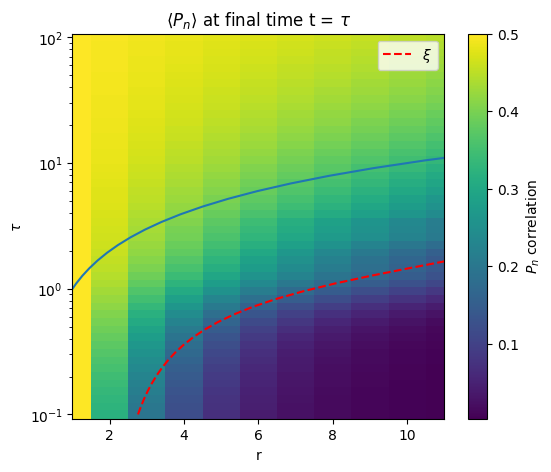
Always a nice visualization

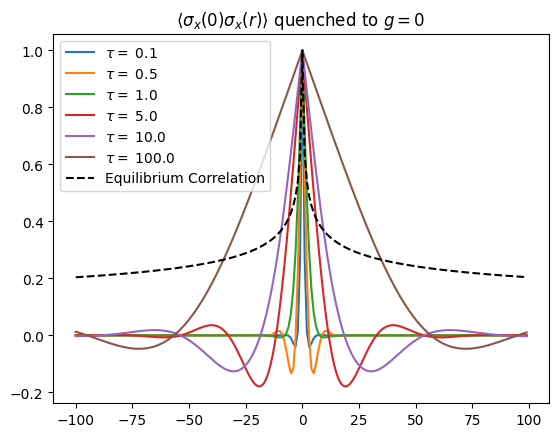

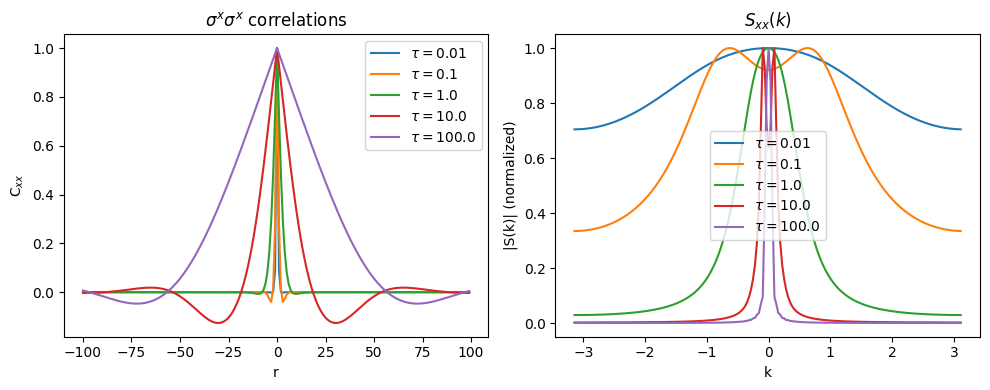

In [13]:
import sys

sys.path.append("../../src")
from common_imports import *
from time_evolved_z_correlators import *

In [2]:
def generate_states(L,taus):
    taus = np.logspace(-1,2,50)

    states = [kz.state(L,tau,tau) for tau in taus]

    return states, taus

def Pt(r,states):
    P = array([P_n_correlations(1,r,s) for s in states])

    return P

In [3]:
########
#Constants
########

L = 100
ns = np.arange(1,10)

In [4]:
states, t = generate_states(L,100)

In [5]:
rs = np.arange(1,20)

In [6]:
data = array([[kz.P_n_correlations(3, ri, s)-kz.P_n(3,s)**2 for ri in rs] for s in states])

figure(figsize=(6, 5))
pcolormesh(rs, t, data, shading='auto', cmap='viridis')
yscale('log')
xlabel('r')
ylabel(r'$\tau$')
colorbar(label=r'$P_n$ correlation')
title(r'$P_n(1,r)$ vs $(r,\tau)$')
show()

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/CFT calculations/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)


NameError: name 'figure' is not defined

In [ ]:
data = array([[kz.P_n_correlations(6, ri, s)-kz.P_n(6,s)**2 for ri in rs] for s in tqdm(states)])

figure(figsize=(6, 5))
pcolormesh(rs, t, data, shading='auto', cmap='viridis')
yscale('log')
xlabel('r')
ylabel(r'$\tau$')
colorbar(label=r'$P_n$ correlation')
title(r'$P_n(1,r)$ vs $(r,\tau)$')
show()

  0%|          | 0/50 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/CFT calculations/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
 72%|███████▏  | 36/50 [18:13<07:07, 30.56s/it]

KeyboardInterrupt: 

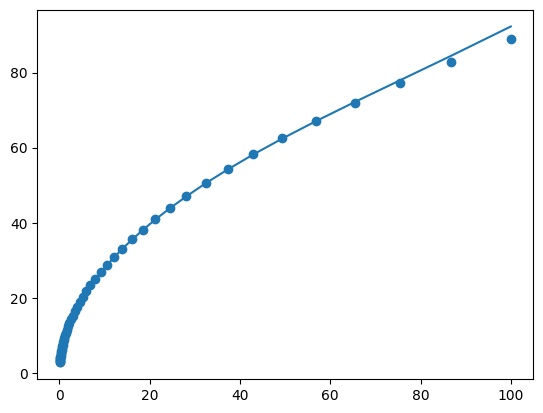

In [ ]:
plot(t,1/p)
scatter(t,sqrt(2*t)*2*pi)

In [7]:
p = array([(1-kz.sigma_general([1,2],s))/2 for s in states])

In [8]:
ns = np.arange(1,12)
data = array([[kz.P_n(ni,s) for ni in ns] for s in tqdm(states)])


100%|██████████| 50/50 [00:11<00:00,  4.49it/s]


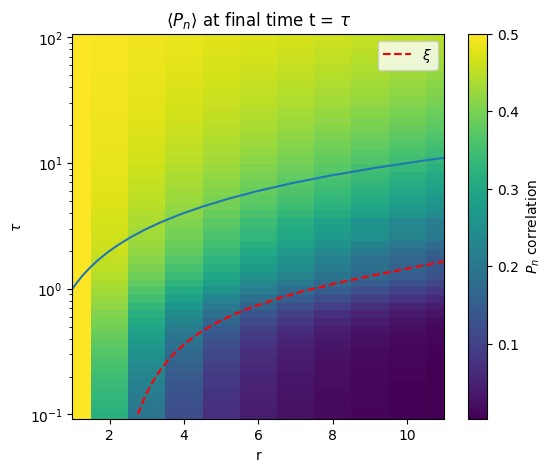

In [ ]:

figure(figsize=(6, 5))
pcolormesh(ns, t, data, shading='auto', cmap='viridis')
yscale("log")
xlabel('r')
ylabel(r'$\tau$')
colorbar(label=r'$P_n$ correlation')
title(r'$\langle P_n \rangle$ at final time t = $\tau$')
plot(1/p, t, 'r--', lw=1.5, label=r'$\xi$')
plot(t,t)
xlim(1,11)
legend()

show()

# Calculating S(k)

In [9]:
import equilibrium_critical_correlations as eq

In [10]:
rs = np.arange(-500,500)
xx = array(
    [eq.sigma_general([0,r]) for r in tqdm(rs)]
    )

#x4 = array([eq.sigma_general([0,1,r,r+1] for r in tqdm(rs))])

  0%|          | 0/1000 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 1000/1000 [00:08<00:00, 111.66it/s]


Text(0, 0.5, '$\\langle \\sigma \\sigma \\rangle$ ')

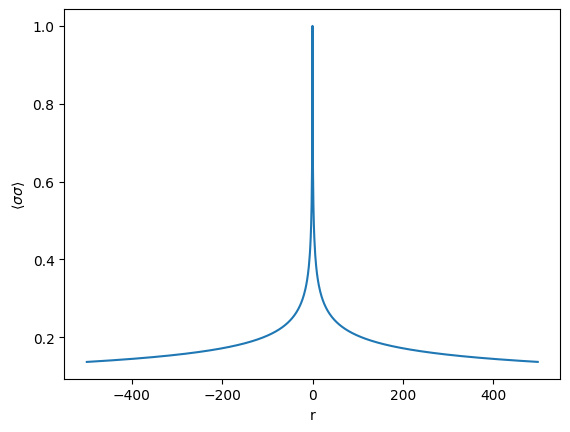

In [11]:
plot(rs,xx)
#plot(rs,x4)
xlabel("r")
ylabel(r"$\langle \sigma \sigma \rangle$ ")

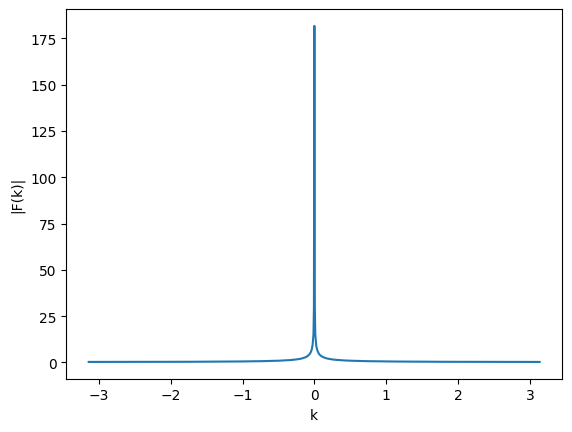

In [16]:
from numpy.fft import fft, fftfreq, fftshift

# assume rs and test are 1D arrays of equal length
N = len(rs)
dr = rs[1] - rs[0]  # spacing
k = fftshift(fftfreq(N, dr)) * 2 * pi  # wave numbers

F = fftshift(fft(xx))  # Fourier transform
plt.figure()
#plot(k, abs(F)/max(abs(F)))
#plot(k,abs(G)/max(abs(G)))
plot(k,abs(F))
# plot(k,F)
# plot(k,G)
xlabel('k')
ylabel('|F(k)|')


show()


# Question: Can we relate the structure factor of $\sigma_x$ to its kibble zurek scaling?

In [305]:
taus = array([.1,0.5,1,5,10,100])

def generate_states(L,taus):

    states = [kz.state(L,tau,tau) for tau in taus]

    return states, taus



In [306]:
states, t = generate_states(300,taus)

rs = np.arange(-100,100)
eq_xx = array([eq.sigma_general([0,ri]) for ri in rs])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


In [307]:
s= states[0]
#prep data
data = np.empty([len(taus),len(rs)])
for i, s in enumerate(tqdm(states)):
    for j, r in enumerate(tqdm(rs)):
        data[i,j] = kz.sigma_general([0,r],s)

  0%|          | 0/6 [00:00<?, ?it/s]
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/CFT calculations/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
































 17%|█▋        | 1/6 [00:06<00:31,  6.22s/it]






























 33%|███▎      | 2/6 [00:12<00:24,  6.20s/it]






























 50%|█████     | 3/6 [00:18<00:18,  6.17s/it]






























 67%|██████▋   | 4/6 [00:24<00:12,  6.15s/it]






























 83%|████████▎ | 5/6 [00:30<00:06,  6.12s/it]































100%|██████████| 6/6 [00:36<00:00,  6.13s/it]


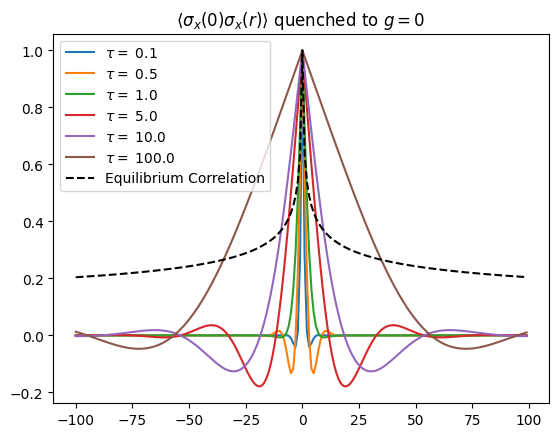

In [308]:
plot(rs,(data.T),label= [r"$\tau=$ "+ str(tau) for tau in taus])
plot(rs,eq_xx,"--k",label="Equilibrium Correlation") 
title(r"$\langle \sigma_x(0) \sigma_x(r) \rangle$ quenched to $g=0$")
legend()
#ylim(.001,1)
##yscale("log")

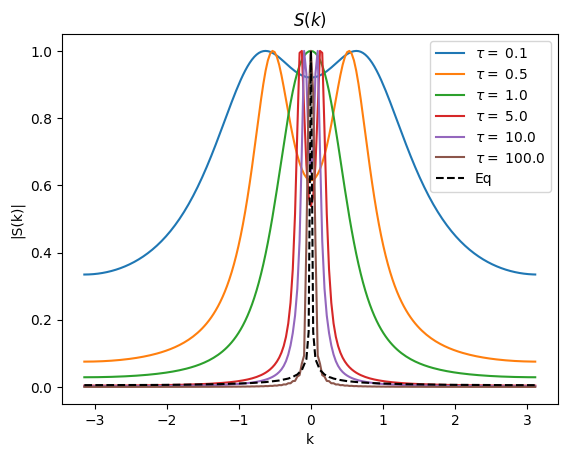

In [312]:
from numpy.fft import fft, fftfreq, fftshift

N = len(rs)
dr = rs[1] - rs[0]  # spacing
k = fftshift(fftfreq(N, dr)) * 2 * pi  # wave numbers

F = np.array([fftshift(fft(d)) * dr for d in data])
F /= np.max(np.abs(F), axis=1, keepdims=True)
G = fftshift(fft(eq_xx))
plt.figure()
#plot(k,abs(F).T, label= [r"$\tau=$ "+ str(tau) for tau in taus])
#plot(k,abs(G),"--k")
plot(k, abs(F).T / abs(F).max(), label=[r"$\tau=$ "+str(tau) for tau in taus])
plot(k, abs(G) / abs(G).max(), "--k",label="Eq")

title(r"$S(k)$")
xlabel('k')
ylabel('|S(k)|')
#ylim(0.1,1)
legend()
#xlim(0,1)
#yscale("log")
show()


# Numerical Integration

In [320]:
from scipy.integrate import simpson as integrate

print(integrate((G)/2/pi,k))

# for i, t in enumerate(taus):
#     print(integrate(abs(F[i,:]/2/pi,k)))

(1.3995057367750406e-07+1.081709694531346e-18j)


In [41]:
s= states[0]
#prep data
data2 = np.empty([len(taus),len(rs)])
for i, s in enumerate(tqdm(states)):
    for j, r in enumerate(tqdm(rs)):
        data2[i,j] = kz.sigma_general([0,1,2,r,r+1,r+2],s)

100%|██████████| 3/3 [00:17<00:00,  5.69s/it]


In [42]:
eq_xx2 = array([eq.sigma_general([0,1,2,ri,ri+1,ri+2]) for ri in rs])

(-0.05, 0.01)

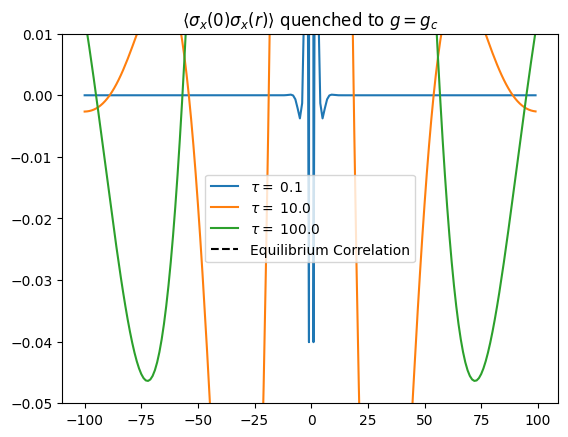

In [43]:
plot(rs,data2.T,label= [r"$\tau=$ "+ str(tau) for tau in taus])
plot(rs,eq_xx2,"--k",label="Equilibrium Correlation") 
title(r"$\langle \sigma_x(0) \sigma_x(r) \rangle$ quenched to $g=g_c$")
#xlim(0,00)
legend()
#yscale("log")
ylim(-.05,.01)

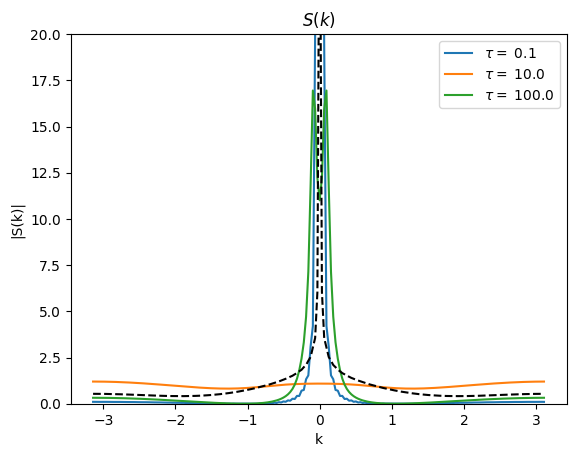

In [44]:
from numpy.fft import fft, fftfreq, fftshift

# assume rs and test are 1D arrays of equal length
N = len(rs)
dr = rs[1] - rs[0]  # spacing
k = fftshift(fftfreq(N, dr)) * 2 * pi  # wave numbers

F = fftshift(fft(data2,axis=1))  # Fourier transform
G = fftshift(fft(eq_xx2))

#plot(k, abs(F)/max(abs(F)))
#plot(k,abs(G)/max(abs(G)))
plot(k,abs(F).T, label= [r"$\tau=$ "+ str(tau) for tau in taus])
plot(k,abs(G),"--k")
# plot(k,F)
# plot(k,G)
title(r"$S(k)$")
xlabel('k')
ylabel('|S(k)|')
ylim(0,20)
legend()
show()


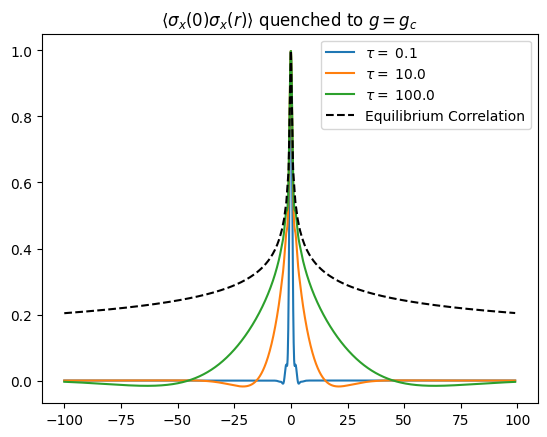

In [53]:
from scipy.interpolate import interp1d
r_fine = np.linspace(rs[0], rs[-1], 2000)

# Ensure data shape matches rs
if data.shape[1] != len(rs):
    data = data[:, :len(rs)]

data_interp = np.array([
    interp1d(rs, data[i], kind='cubic')(r_fine)
    for i in range(data.shape[0])
])

plot(r_fine, data_interp.T, label=[r"$\tau=$ " + str(tau) for tau in taus])
plot(rs, eq_xx, "--k", label="Equilibrium Correlation")
title(r"$\langle \sigma_x(0) \sigma_x(r) \rangle$ quenched to $g=g_c$")
legend()


# Equilibrium String Projectors

Now we try the same type of analysis but with different types of projectors

In [168]:
import equilibrium_z_projectors as ez

In [176]:

eq_xx = array([eq.sigma_general([0,r]) for r in rs])
eq_zz = array([ez.sigma_general([0,r])-ez.sigma_general([0])**2 for r in rs])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


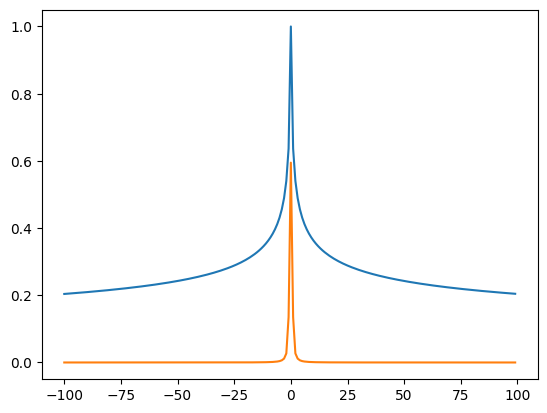

In [177]:
plot(rs,eq_xx)
plot(rs,eq_zz)

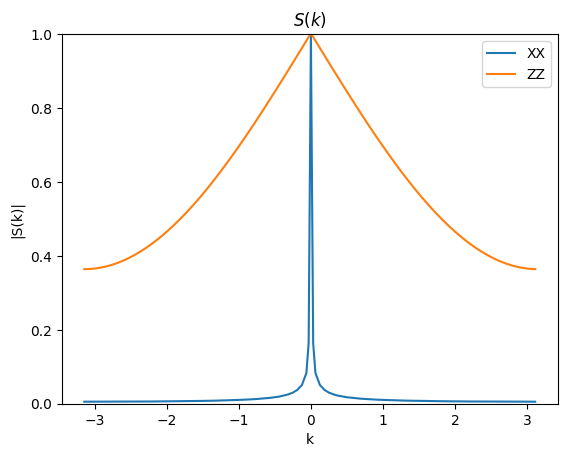

In [182]:

# assume rs and test are 1D arrays of equal length
N = len(rs)
dr = rs[1] - rs[0]  # spacing
k = fftshift(fftfreq(N, dr)) * 2 * pi  # wave numbers

F = fftshift(fft(eq_xx))  # Fourier transform
G = fftshift(fft(eq_zz))

#plot(k, abs(F)/max(abs(F)))
#plot(k,abs(G)/max(abs(G)))
plot(k,abs(F)/max(abs(F)),label="XX")#, label= [r"$\tau=$ "+ str(tau) for tau in taus])
plot(k,abs(G)/max(abs(G)),label="ZZ")
# plot(k,F)
# plot(k,G)
title(r"$S(k)$")
xlabel('k')
ylabel('|S(k)|')
ylim(0,1)
legend()
show()


I make a simple argument. Tha tbecause of this, $$\int dk= \Lambda$$ and $$\Lambda = \frac{1}{\xi}$$ that:

$\xi$ will be higher for the $x$ spins than for the $z$ spins.

$\xi$ will be lower for the $z$ spins than the for the $x$ spins. 

In other words, after quenching, I shoiuld see more error with $z$ than I do with $x$

In [196]:
from time_evolved_z_correlators import sigma_general as time_sigmaz

In [222]:
taus = np.logspace(-2,2,5)
states,t =generate_states(200,taus)
rs

array([-100,  -99,  -98,  -97,  -96,  -95,  -94,  -93,  -92,  -91,  -90,
        -89,  -88,  -87,  -86,  -85,  -84,  -83,  -82,  -81,  -80,  -79,
        -78,  -77,  -76,  -75,  -74,  -73,  -72,  -71,  -70,  -69,  -68,
        -67,  -66,  -65,  -64,  -63,  -62,  -61,  -60,  -59,  -58,  -57,
        -56,  -55,  -54,  -53,  -52,  -51,  -50,  -49,  -48,  -47,  -46,
        -45,  -44,  -43,  -42,  -41,  -40,  -39,  -38,  -37,  -36,  -35,
        -34,  -33,  -32,  -31,  -30,  -29,  -28,  -27,  -26,  -25,  -24,
        -23,  -22,  -21,  -20,  -19,  -18,  -17,  -16,  -15,  -14,  -13,
        -12,  -11,  -10,   -9,   -8,   -7,   -6,   -5,   -4,   -3,   -2,
         -1,    0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
         10,   11,   12,   13,   14,   15,   16,   17,   18,   19,   20,
         21,   22,   23,   24,   25,   26,   27,   28,   29,   30,   31,
         32,   33,   34,   35,   36,   37,   38,   39,   40,   41,   42,
         43,   44,   45,   46,   47,   48,   49,   

In [226]:
rho_x = array([[kz.sigma_general([0, r], s) for r in tqdm(rs)] for s in states])
rho_z = array([[time_sigmaz([0, r], s)-time_sigmaz([0],s)**2 for r in rs] for s in states])



/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/CFT calculations/../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)



























100%|██████████| 200/200 [00:05<00:00, 38.47it/s]




























100%|██████████| 200/200 [00:05<00:00, 38.45it/s]


























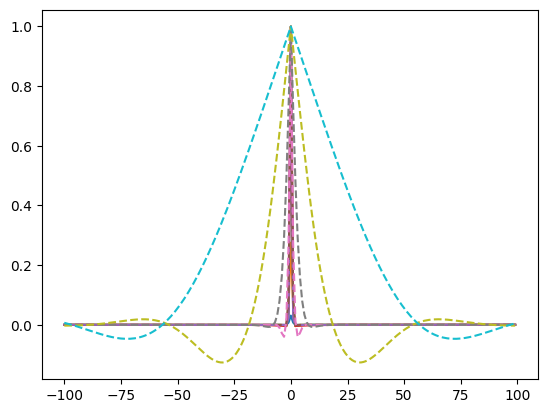

In [229]:
plot(rs,rho_z.T)
plot(rs,rho_x.T,ls="--")


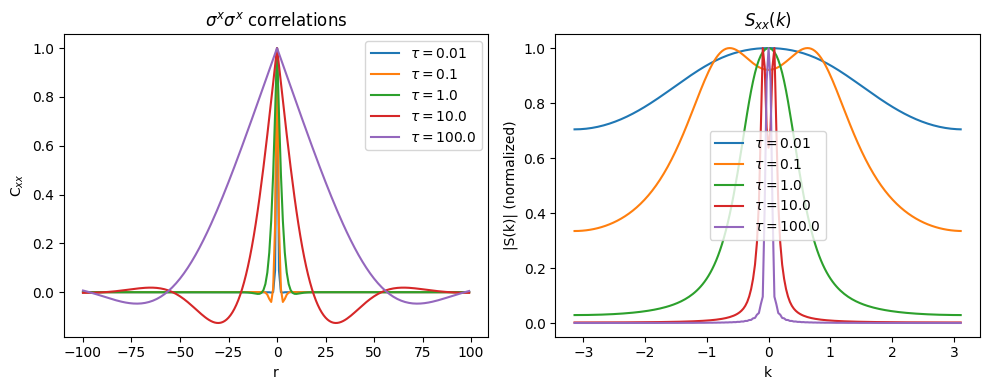

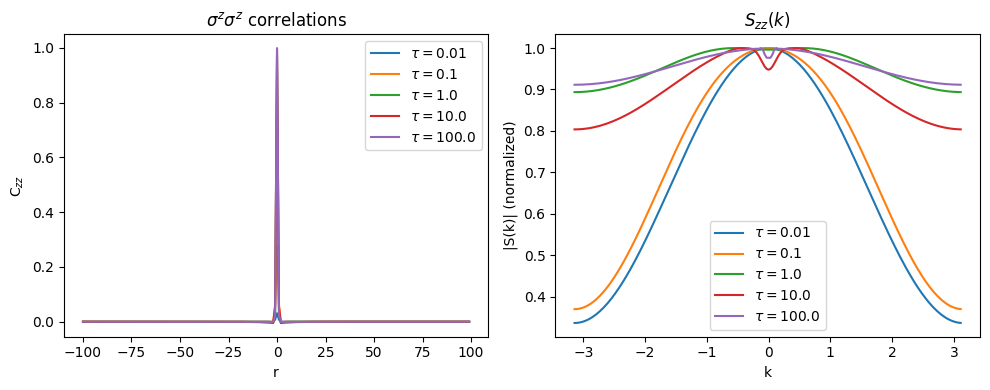

In [232]:
from numpy.fft import fft, fftfreq, fftshift
import matplotlib.pyplot as plt
import numpy as np

# assume rs, taus, rho_x, rho_z defined
dr = rs[1] - rs[0]
N = len(rs)
k = fftshift(fftfreq(N, dr)) * 2 * np.pi

# Fourier transform each τ separately
Fx = np.array([fftshift(fft(r)) for r in rho_x])
Fz = np.array([fftshift(fft(r)) for r in rho_z])

# ---- X-X correlations ----
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, tau in enumerate(taus):
    ax[0].plot(rs, rho_x[i], label=fr"$\tau={tau}$")
    ax[1].plot(k, np.abs(Fx[i]) / np.abs(Fx[i]).max(), label=fr"$\tau={tau}$")

ax[0].set_title(r"$\sigma^x\sigma^x$ correlations")
ax[0].set_xlabel("r")
ax[0].set_ylabel("C$_{xx}$")
ax[0].legend()

ax[1].set_title(r"$S_{xx}(k)$")
ax[1].set_xlabel("k")
ax[1].set_ylabel("|S(k)| (normalized)")
ax[1].legend()
plt.tight_layout()
plt.show()

# ---- Z-Z correlations ----
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, tau in enumerate(taus):
    ax[0].plot(rs, rho_z[i], label=fr"$\tau={tau}$")
    ax[1].plot(k, np.abs(Fz[i]) / np.abs(Fz[i]).max(), label=fr"$\tau={tau}$")

ax[0].set_title(r"$\sigma^z\sigma^z$ correlations")
ax[0].set_xlabel("r")
ax[0].set_ylabel("C$_{zz}$")
ax[0].legend()

ax[1].set_title(r"$S_{zz}(k)$")
ax[1].set_xlabel("k")
ax[1].set_ylabel("|S(k)| (normalized)")
ax[1].legend()
plt.tight_layout()
plt.show()


In [278]:
eq_xx = array([eq.sigma_general([0,r]) for r in rs])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


<module 'equilibrium_critical_correlations' from '/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/CFT calculations/../../src/equilibrium_critical_correlations.py'>

In [271]:
rs = np.arange(0,100)
P11= array([eq.P_n_correlations(1,r)-eq.P_n(1)**2 for r in rs])
P22= array([eq.P_n_correlations(2,r)-eq.P_n(2)**2 for r in rs])
P33= array([eq.P_n_correlations(3,r)-eq.P_n(3)**2 for r in rs])
P44= array([eq.P_n_correlations(4,r)-eq.P_n(4)**2 for r in rs])
P55= array([eq.P_n_correlations(5,r)-eq.P_n(5)**2 for r in rs])

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


[]

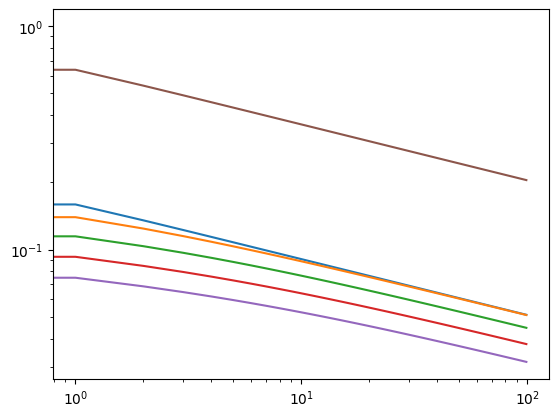

In [279]:
plot(rs,P11)
plot(rs,P22)
plot(rs,P33)
plot(rs,P44)
plot(rs,P55)
plot(rs,eq_xx)
loglog()

In [280]:
F1 = np.array(fftshift(fft(P11)))
F2 = np.array(fftshift(fft(P22)))
F3 = np.array(fftshift(fft(P33)))
F4 = np.array(fftshift(fft(P44)))
F5 = np.array(fftshift(fft(P55)))
F_xx= np.array(fftshift(fft(eq_xx)))

dr = rs[1]-rs[0]
N = len(rs)
k = fftshift(fftfreq(N, dr)) * 2 * np.pi


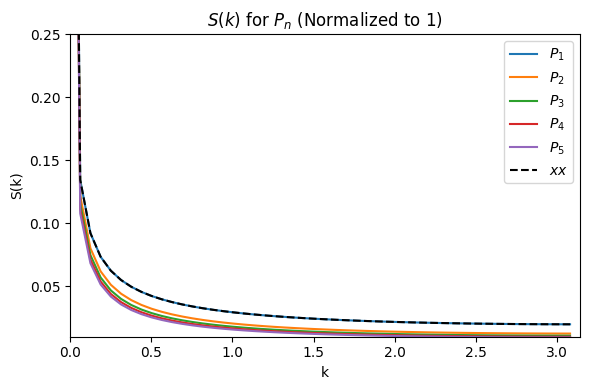

In [304]:
plt.figure(figsize=(6,4))
plt.plot(k, np.abs(F1)/np.max(np.abs(F1)), label=r"$P_1$")
plt.plot(k, np.abs(F2)/np.max(np.abs(F2)), label=r"$P_2$")
plt.plot(k, np.abs(F3)/np.max(np.abs(F3)), label=r"$P_3$")
plt.plot(k, np.abs(F4)/np.max(np.abs(F4)), label=r"$P_4$")
plt.plot(k, np.abs(F5)/np.max(np.abs(F5)), label=r"$P_5$")
plt.plot(k, np.abs(F_xx)/np.max(np.abs(F_xx)), "--k",label=r"$xx$",)

#plt.yscale("log")
plt.xlabel("k")
plt.ylabel("S(k)")
xlim(0.0,3.14)
ylim(.01,.25)
#xscale("log")
plt.legend()
plt.title(r"$S(k)$ for $P_n$ (Normalized to 1)")
plt.tight_layout()
plt.show()


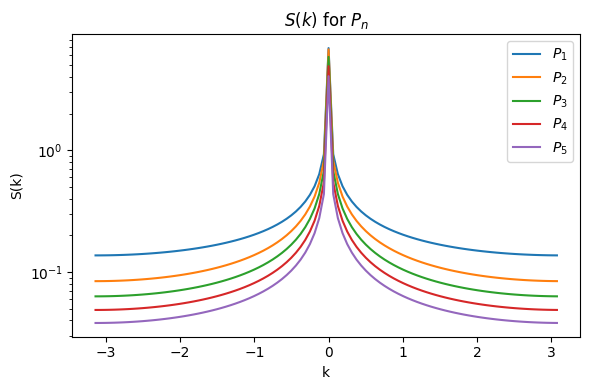

In [277]:
plt.figure(figsize=(6,4))
plt.plot(k, np.abs(F1), label=r"$P_1$")
plt.plot(k, np.abs(F2), label=r"$P_2$")
plt.plot(k, np.abs(F3), label=r"$P_3$")
plt.plot(k, np.abs(F4), label=r"$P_4$")
plt.plot(k, np.abs(F5), label=r"$P_5$")

plt.yscale("log")
plt.xlabel("k")
plt.ylabel("S(k)")
plt.legend()
plt.title(r"$S(k)$ for $P_n$")
plt.tight_layout()
plt.show()
